Exploratory Data Analysis (EDA) is the process of analyzing and summarizing a cleaned dataset to understand its patterns, distributions, relationships, and characteristics before building Machine Learning models.

Outliers : An outlier is a value that is unusually high or unusually low compared to the rest of the data.

there are 5 steps to calculate the outlayers and remove outlayers


In [25]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
#Load the CSV File
df = pd.read_csv("weight-height.csv")

print(df.head())

  Gender     Height      Weight
0   Male  73.847017  241.893563
1   Male  68.781904  162.310473
2   Male  74.110105  212.740856
3   Male  71.730978  220.042470
4   Male  69.881796  206.349801


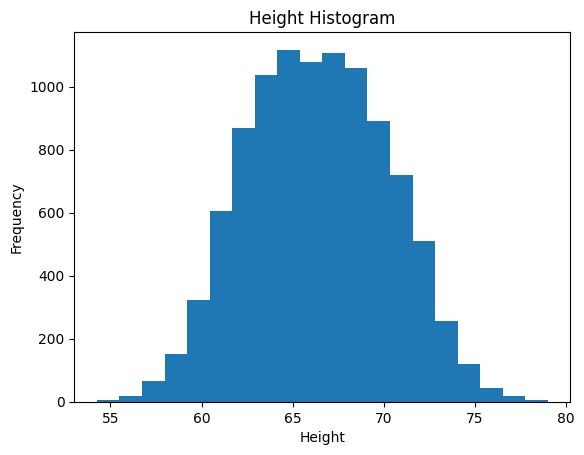

In [27]:
#plot histogram  of height
plt.hist(df["Height"], bins=20)
plt.title("Height Histogram")
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.show()

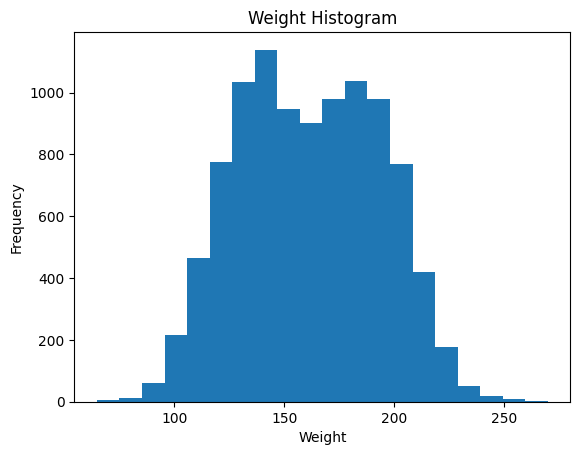

In [28]:
# plot histogram of weight
plt.hist(df["Weight"], bins=20)
plt.title("Weight Histogram")
plt.xlabel("Weight")
plt.ylabel("Frequency")
plt.show()

In [29]:
#IQR = Q3 - Q1
#Lower Limit = Q1 - 1.5 × IQR
#Upper Limit = Q3 + 1.5 × IQR using quantile
# detecting weight outlier using IQR
#detecting height outlier using IQR
Q1 = df["Weight"].quantile(0.25)
Q3 = df["Weight"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

weight_outliers = df[(df["Weight"] < lower) | (df["Weight"] > upper)]

print(weight_outliers)

     Gender     Height      Weight
2014   Male  78.998742  269.989699


In [30]:
# Replace weight outliers with mean
mean_weight = df["Weight"].mean()

Q1 = df["Weight"].quantile(0.25)
Q3 = df["Weight"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df["Weight"] = df["Weight"].apply(
    lambda x: mean_weight if x < lower or x > upper else x
)

print(df)

      Gender     Height      Weight
0       Male  73.847017  241.893563
1       Male  68.781904  162.310473
2       Male  74.110105  212.740856
3       Male  71.730978  220.042470
4       Male  69.881796  206.349801
...      ...        ...         ...
9995  Female  66.172652  136.777454
9996  Female  67.067155  170.867906
9997  Female  63.867992  128.475319
9998  Female  69.034243  163.852461
9999  Female  61.944246  113.649103

[10000 rows x 3 columns]


In [31]:
# replace height outliers with Median
median_height = df["Height"].median()

Q1 = df["Height"].quantile(0.25)
Q3 = df["Height"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df["Height"] = df["Height"].apply(
    lambda x: median_height if x < lower or x > upper else x
)

print(df)

      Gender     Height      Weight
0       Male  73.847017  241.893563
1       Male  68.781904  162.310473
2       Male  74.110105  212.740856
3       Male  71.730978  220.042470
4       Male  69.881796  206.349801
...      ...        ...         ...
9995  Female  66.172652  136.777454
9996  Female  67.067155  170.867906
9997  Female  63.867992  128.475319
9998  Female  69.034243  163.852461
9999  Female  61.944246  113.649103

[10000 rows x 3 columns]
